Part 1 – Get to Know the Dataset

1. Load the CSV file into pandas. What are the dimensions of the dataset?

    Display the first 5 rows.
    Report the number of rows and columns.

In [60]:
import pandas as pd

df = pd.read_csv("/content/SLCM_Basic_Needs_Class_Practice(1).csv")
df.head()

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
0,Renter - past due rent,1200.0,0,Yes,225.0,200.0,No,1,Yes,Never
1,Renter - past due rent,0.0,1,No,217.0,144.0,No,2,Yes,Never
2,Staying with friends or family,800.0,4,No,100.0,100.0,No,5,Yes,Sometimes
3,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never
4,Homeless,0.0,3,No,0.0,0.0,Yes,3,Yes,Rarely


In [61]:
df.shape

(166, 10)

2. What variables are available?

    Print the column names.
    For each variable, write one short sentence describing what you think it represents.


In [62]:
df.columns

Index(['Housing_Status', 'Monthly_Housing_Cost', 'Moves_Last_3_Years',
       'Utility_Disconnection_Risk', 'Monthly_LGE_Bill', 'Monthly_Water_Bill',
       'Eviction_Record', 'Transportation_Need_Score', 'Has_Car', 'Bus_Use'],
      dtype='object')

Housing_status - if someone owns a home, homeless, renting an apartment, etc

Monthly_Housing_Cost - how much one pays for housing in a month

Moves_Last_3_Years - amount of times one has moved homes in the last 3 years

Utility_Disconnection_Risk - if one is at risk to lose access to their utilities

Monthly_LGE_Bill - How much one pays for LGE utility bill

Monthly_Water_Bill - How much one pays for water bill

Eviction_Record - If one has an eviction record or not

Transporation_Need_Score - High number if one needs transportation, low if not, [0->5]

Has_Car - If one has a car

Bus_Use - Frequency of one's bus use if they use it or not


3. What data types did pandas assign to the variables?

    Use info() and/or dtypes.
    Which columns are numeric?
    Which columns are categorical/object?
    Does any column have a data type that makes you want to inspect it more closely? Explain.

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              166 non-null    object 
 1   Monthly_Housing_Cost        166 non-null    float64
 2   Moves_Last_3_Years          166 non-null    object 
 3   Utility_Disconnection_Risk  166 non-null    object 
 4   Monthly_LGE_Bill            166 non-null    float64
 5   Monthly_Water_Bill          166 non-null    float64
 6   Eviction_Record             166 non-null    object 
 7   Transportation_Need_Score   166 non-null    int64  
 8   Has_Car                     166 non-null    object 
 9   Bus_Use                     166 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 13.1+ KB


Numeric Columns - Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, Transportation_Need_Score

Categorical Columns - Housing_Status, Moves_Last_3_Years, Utility_Disconnection_Risk, Eviction_Record, Has_Car, Bus_Use

Columns that are a little questionable:
- Moves_Last_3_Years is categorical, but mostly uses numbers 0-4, with the exception of the category "more than 5"
- Monthly_Housing_Cost, Monthly_LGE_Bill, and Monthly_Water_Bill all show 0 even in cases where there is a renter
- Utility_Disconnection_Risk has an ambigious "maybe" category
- Eviction_Record has an ambiguous "Not sure" category


4. What values occur in each categorical variable?

    Use value_counts() for Housing_Status, Utility_Disconnection_Risk, Eviction_Record, Has_Car, Bus_Use, and Moves_Last_3_Years.
    Which categories are most common?
    Do you notice any values that may need clarification or cleaning?


In [64]:
df.value_counts("Housing_Status")

,count
Housing_Status,
Renter - no rent past due,68
Renter - past due rent,51
Homeless,19
Staying at extended stay hotel or short-term housing,15
Staying with friends or family,12
Own home - mortgage past due,1


In [65]:
df.value_counts("Utility_Disconnection_Risk")

,count
Utility_Disconnection_Risk,
No,116
Yes,40
Maybe,10


In [66]:
df.value_counts("Eviction_Record")

,count
Eviction_Record,
No,114
Yes,42
Not sure,10


In [67]:
df.value_counts("Has_Car")

,count
Has_Car,
Yes,87
No,79


In [68]:
df.value_counts("Bus_Use")

,count
Bus_Use,
Never,66
Often,47
Sometimes,35
Rarely,18


In [69]:
df.value_counts("Moves_Last_3_Years")

,count
Moves_Last_3_Years,
1,43
2,40
0,34
3,20
More than 5,15
4,10
5,4


Generally, when there is an option where one doesn't have to pay a bill, that is the most common

Moves_Last_3_Years is too ambiguous having a more than 5 option, and so is the maybe category for Utility_Disconnection_Risk

Part 2 – Investigate Data Quality

5. Are there missing values or duplicate rows?

    Calculate the number of missing values in every column.
    Check for duplicate rows.
    Report what you find.


In [70]:
df.isna().sum()

,0
Housing_Status,0
Monthly_Housing_Cost,0
Moves_Last_3_Years,0
Utility_Disconnection_Risk,0
Monthly_LGE_Bill,0
Monthly_Water_Bill,0
Eviction_Record,0
Transportation_Need_Score,0
Has_Car,0
Bus_Use,0


In [71]:
df.duplicated().sum()

np.int64(1)

In [72]:
df[df.duplicated()]

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
42,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never


There are no missing values (then again there are sections where it shows 0 on a bill for someone who should have a bill, but nothing is null i suppose)

There is 1 duplicate value

This data is essentially filled enough, but some values are false or just too ambiguous which warrents the data needing to be cleaned up

6. What do the numeric variables look like?

    Use describe() for Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, and Transportation_Need_Score.
    For each variable, identify its minimum, maximum, and typical values.
    Which values look unusual or deserve a closer look?


In [73]:
df.describe()

,Monthly_Housing_Cost,Monthly_LGE_Bill,Monthly_Water_Bill,Transportation_Need_Score
count,166.000000,166.000000,166.000000,166.000000
mean,625.209181,420.003320,42.167815,2.433735
std,560.109409,3587.214867,99.524462,1.796918
min,0.000000,0.000000,0.000000,0.000000
25%,0.010000,0.010000,0.000000,1.000000
50%,550.000000,120.000000,0.010000,3.000000
75%,1100.000000,200.000000,60.000000,4.000000
max,2000.000000,46247.000000,1000.000000,5.000000


Each have 0 as the minimum, which would make sense if they were all homeless, but the majority are not.
The maximum LGE bill is at 46k which is absurd and skews the rest of the values
The maximum Water bill is at 1000, but 50% of people pay 1 dollar on average? Both of those don't make sense.

7. Investigate zero values.

    Count how many records have Monthly_Housing_Cost = 0.
    Count how many records have Monthly_LGE_Bill = 0 and Monthly_Water_Bill = 0.
    Look at Housing_Status for records with Monthly_Housing_Cost = 0.
    Does a zero always appear to mean "bad data"? Explain what else zero could reasonably mean in this dataset.


In [74]:
df.loc[df["Monthly_Housing_Cost"] == 0].shape

(31, 10)

In [75]:
df.loc[(df["Monthly_LGE_Bill"] == 0) & (df["Monthly_Water_Bill"] == 0)].shape

(36, 10)

In [76]:
df.loc[df["Monthly_Housing_Cost"] == 0]["Housing_Status"].value_counts()

,count
Housing_Status,
Renter - no rent past due,14
Homeless,13
Staying with friends or family,2
Renter - past due rent,1
Staying at extended stay hotel or short-term housing,1


No 0 does not *always* mean bad data, it mostly depends on the context.
The homeless having no monthly housing cost makes sense, however, renters with no monthly housing cost does not make sense. There are zeros in values where there shouldn't be which is the issue.

8. Investigate Moves_Last_3_Years.

    Display all unique values and their counts.
    Can the values be used directly as numbers?
    If not, explain how you would clean or recode this variable for future analysis.


In [77]:
#Display all unique values and their counts.
df.value_counts()

Housing_Status                  Monthly_Housing_Cost  Moves_Last_3_Years  Utility_Disconnection_Risk  Monthly_LGE_Bill  Monthly_Water_Bill  Eviction_Record  Transportation_Need_Score  Has_Car  Bus_Use  
Homeless                        0.0                   2                   No                          0.000             0.0000              Yes              0                          Yes      Never        2
                                                      0                   No                          0.000             0.0000              No               4                          Yes      Never        1
                                                                                                                                                             5                          No       Often        1
                                                      1                   No                          0.000             0.0000              No               5                          Yes      Sometimes    1
                                                      0                   No                          0.000             0.0000              No               4                          No       Sometimes    1
                                                                                                                                                                                                             ..
Staying with friends or family  320.0                 2                   No                          260.000           0.0001              Yes              0                          Yes      Never        1
                                400.0                 1                   No                          100.000           100.0000            No               4                          Yes      Never        1
                                550.0                 More than 5         No                          70.000            0.0100              No               5                          No       Often        1
                                800.0                 4                   No                          100.000           100.0000            No               5                          Yes      Sometimes    1
                                1000.0                3                   No                          0.001             0.0010              No               2                          Yes      Never        1
Name: count, Length: 165, dtype: int64

It cannot be used directly as numbers because of the option "More than 5" which uses characters.
To fix this, we can remove all elements that have that option from the dataset to allow us to use Moves_Last_3_Years as numbers rather than characters

9. Make a cleaned working copy of the dataset.

    Create a new DataFrame for your cleaned data.
    Make at least TWO reasonable cleaning/preparation changes based on what you found above.
    For each change, explain exactly what you changed and why.
    Run checks afterward to verify that the changes worked.


In [78]:
#make a new cleaned up dataframe based on df
clean_df = df.copy();

In [79]:
#remove every element that shows more than 5 in Moves_Last_3_Years
clean_df = clean_df.loc[clean_df["Moves_Last_3_Years"] != "More than 5"]

In [80]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              151 non-null    object 
 1   Monthly_Housing_Cost        151 non-null    float64
 2   Moves_Last_3_Years          151 non-null    object 
 3   Utility_Disconnection_Risk  151 non-null    object 
 4   Monthly_LGE_Bill            151 non-null    float64
 5   Monthly_Water_Bill          151 non-null    float64
 6   Eviction_Record             151 non-null    object 
 7   Transportation_Need_Score   151 non-null    int64  
 8   Has_Car                     151 non-null    object 
 9   Bus_Use                     151 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 13.0+ KB


In [81]:
#drop the duplicates
clean_df = clean_df.drop_duplicates()

In [82]:
#make moves last 3 years numerical now that there are no characters
clean_df["Moves_Last_3_Years"] = pd.to_numeric(clean_df["Moves_Last_3_Years"])

In [83]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              150 non-null    object 
 1   Monthly_Housing_Cost        150 non-null    float64
 2   Moves_Last_3_Years          150 non-null    int64  
 3   Utility_Disconnection_Risk  150 non-null    object 
 4   Monthly_LGE_Bill            150 non-null    float64
 5   Monthly_Water_Bill          150 non-null    float64
 6   Eviction_Record             150 non-null    object 
 7   Transportation_Need_Score   150 non-null    int64  
 8   Has_Car                     150 non-null    object 
 9   Bus_Use                     150 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 12.9+ KB


Part 3 – Guided Exploration and Visualization

10. What does housing status look like in this dataset?

    Create a frequency table for Housing_Status.
    Create an appropriate visualization.
    Which housing status is most common? What do you notice about the overall distribution?


In [84]:
#create frequency table for housing_status
clean_df.value_counts("Housing_Status")

,count
Housing_Status,
Renter - no rent past due,60
Renter - past due rent,49
Homeless,16
Staying at extended stay hotel or short-term housing,14
Staying with friends or family,10
Own home - mortgage past due,1


Renters are the most common, more particularly people who have paid their rent in time
Overall, it's surprising to see only one person in this dataset owning a home

11. How does monthly housing cost vary across housing situations?

    Compare Monthly_Housing_Cost across Housing_Status.
    Use a suitable summary and/or visualization.
    What pattern do you notice?
    Be careful when interpreting zero housing cost. Explain why.


In [85]:
clean_df.groupby("Housing_Status")["Monthly_Housing_Cost"].mean()

,Monthly_Housing_Cost
Housing_Status,
Homeless,56.314375
Own home - mortgage past due,1376.020000
Renter - no rent past due,594.950350
Renter - past due rent,913.081837
Staying at extended stay hotel or short-term housing,793.785714
Staying with friends or family,252.002300


It says the homeless have a monthly housing cost which is false, but that's another 12% of the dataset so I'll just bear with it
Mortgages, or more specifically the one home owner pays quite a lot per month

People that stay with friends/family don't pay very much, which makes sense



12. Is utility disconnection risk associated with a different LG&E bill pattern?

    Compare Monthly_LGE_Bill for people with different Utility_Disconnection_Risk values.
    Create an appropriate visualization.
    Describe what you observe. Do not claim that one variable causes the other.


/tmp/ipykernel_1835/2820868158.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Utility_Disconnection_Risk', y='Monthly_LGE_Bill', data=monthly_lge_bill_by_risk, palette='viridis')


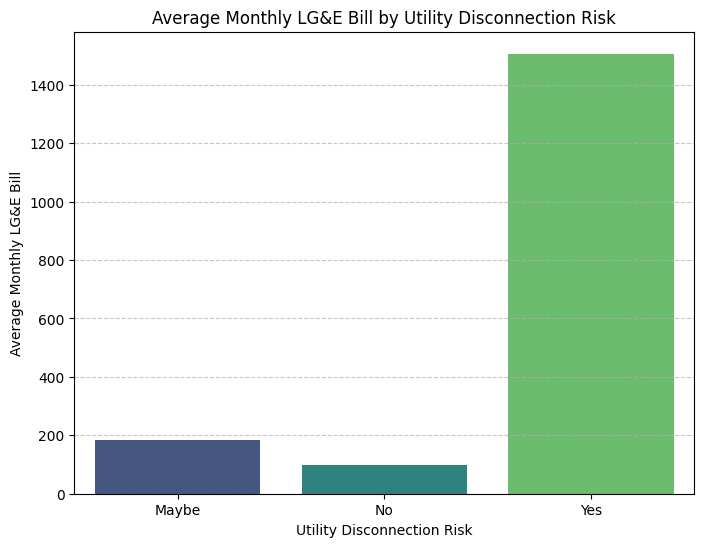

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean Monthly_LGE_Bill for each Utility_Disconnection_Risk category
monthly_lge_bill_by_risk = clean_df.groupby('Utility_Disconnection_Risk')['Monthly_LGE_Bill'].mean().reset_index()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Utility_Disconnection_Risk', y='Monthly_LGE_Bill', data=monthly_lge_bill_by_risk, palette='viridis')
plt.title('Average Monthly LG&E Bill by Utility Disconnection Risk')
plt.xlabel('Utility Disconnection Risk')
plt.ylabel('Average Monthly LG&E Bill')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I believe this shows that when the LGE bill is too high, people tend to start to fall behind on their payments and lose access to their utilities

13. What does transportation need look like for people with and without a car?

    Compare Transportation_Need_Score by Has_Car.
    Use summary statistics and a visualization.
    Does car ownership appear related to transportation need in this dataset? Explain using evidence.

/tmp/ipykernel_1835/3654698556.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Has_Car', y='Transportation_Need_Score', palette='pastel')


Summary Statistics of Transportation Need Score by Car Ownership:
         count      mean       std  min  25%  50%  75%  max
Has_Car                                                    
No        69.0  3.246377  1.566241  0.0  2.0  4.0  5.0  5.0
Yes       81.0  1.617284  1.707102  0.0  0.0  1.0  3.0  5.0


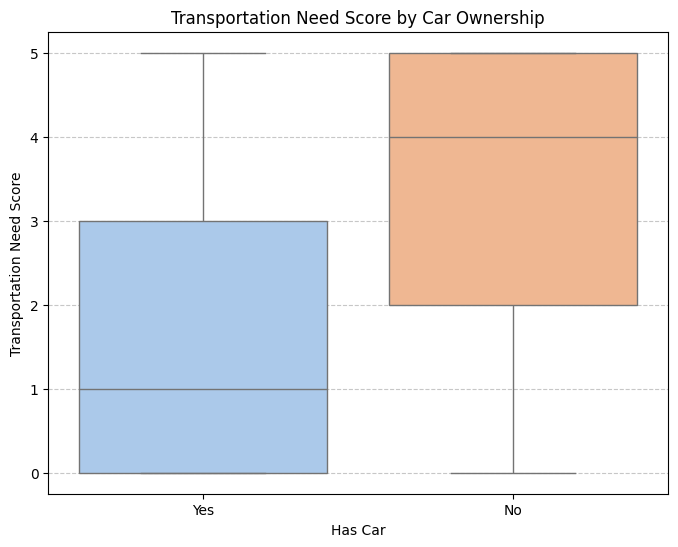

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics for Transportation_Need_Score by Has_Car
summary_stats = clean_df.groupby('Has_Car')['Transportation_Need_Score'].describe()
print("Summary Statistics of Transportation Need Score by Car Ownership:")
print(summary_stats)

# Create a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='Has_Car', y='Transportation_Need_Score', palette='pastel')
plt.title('Transportation Need Score by Car Ownership')
plt.xlabel('Has Car')
plt.ylabel('Transportation Need Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In this dataset, it is evident that when someone has a car, their need for transportation is generally low , whereas when one does not have a car, they typically need transportation more.

14. How is bus use distributed?

    Create a frequency table and visualization for Bus_Use.
    What is the most common bus-use category?
    What additional variable would you compare with Bus_Use if you wanted to understand transportation needs better? Why?


In [88]:
#create a frequency table for bus use
clean_df.value_counts("Bus_Use")

,count
Bus_Use,
Never,63
Often,39
Sometimes,31
Rarely,17


/tmp/ipykernel_1835/2765463402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=clean_df, x='Bus_Use', y='Transportation_Need_Score', palette='pastel')


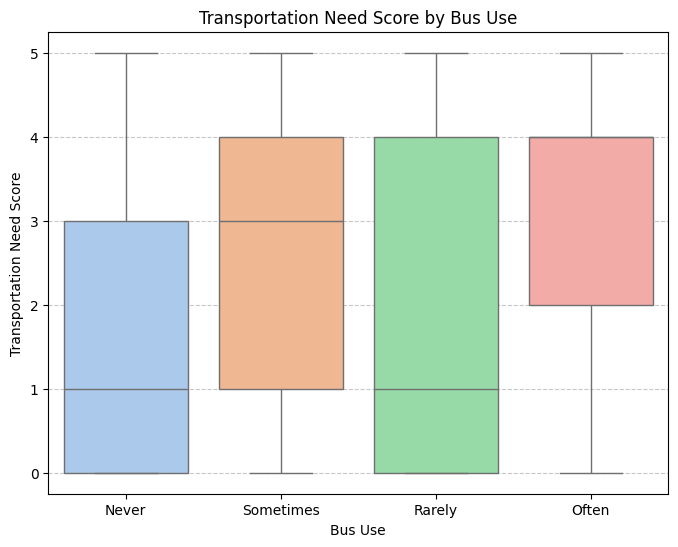

In [89]:
#now create a visualization, preferrably a box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=clean_df, x='Bus_Use', y='Transportation_Need_Score', palette='pastel')
plt.title('Transportation Need Score by Bus Use')
plt.xlabel('Bus Use')
plt.ylabel('Transportation Need Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [90]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              150 non-null    object 
 1   Monthly_Housing_Cost        150 non-null    float64
 2   Moves_Last_3_Years          150 non-null    int64  
 3   Utility_Disconnection_Risk  150 non-null    object 
 4   Monthly_LGE_Bill            150 non-null    float64
 5   Monthly_Water_Bill          150 non-null    float64
 6   Eviction_Record             150 non-null    object 
 7   Transportation_Need_Score   150 non-null    int64  
 8   Has_Car                     150 non-null    object 
 9   Bus_Use                     150 non-null    object 
dtypes: float64(3), int64(2), object(5)
memory usage: 12.9+ KB


The most common Bus_Use categroy is "Never."
An additional category that could help would be "Has_Car" since if they have one there's no need for a Bus of course.

Part 4 – Your Question

Now that you have worked through the guided exploration, ask ONE question of your own. Your question must be answerable using variables in this dataset and should investigate something you genuinely noticed or became curious about.

15. MY QUESTION: Does Bus_Use correlate to Has_Car in any notable way?


In [91]:
#compare bus_use and has_car in value_counts
clean_df.groupby(["Bus_Use", "Has_Car"]).size().unstack()

Has_Car,No,Yes
Bus_Use,,
Never,12,51
Often,36,3
Rarely,5,12
Sometimes,16,15


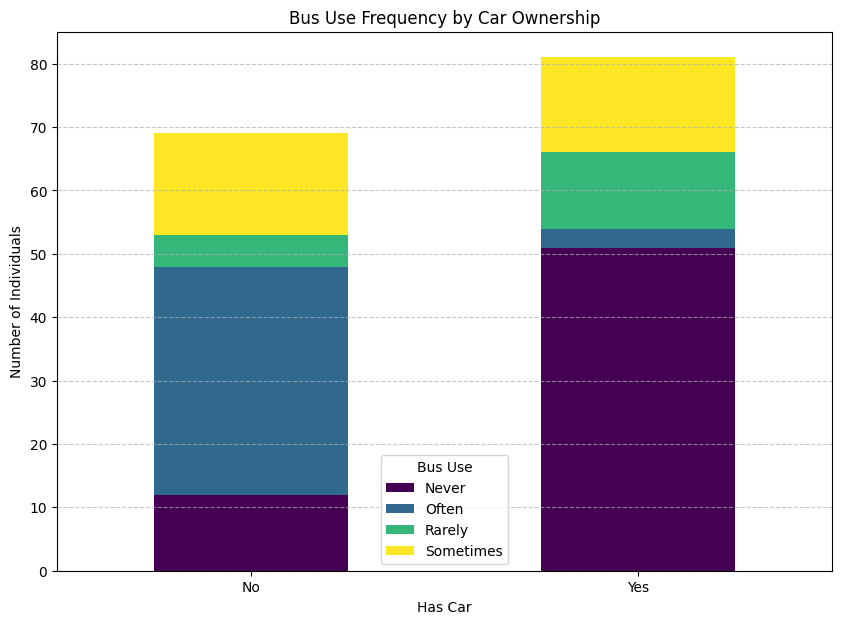

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a contingency table
contingency_table = clean_df.groupby(['Has_Car', 'Bus_Use']).size().unstack(fill_value=0)

# Plotting a stacked bar chart
contingency_table.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
plt.title('Bus Use Frequency by Car Ownership')
plt.xlabel('Has Car')
plt.ylabel('Number of Individuals')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Bus Use')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Based on both the table and the stacked box chart, there does exist a correlation between the categories "Bus_Use" and "Has_Car." If one has a car, they are more than 4 times more likely to never use the bus, and more than 3 times likely to rarely use a bus, so this correlation is very important in understanding the Bus_Use category

I chose the category "Has_Car" because I believe it is the most contextually relevant category relating to bus use than the others

I was curious because of the previous question

It is useful to understand because the previous question didn't really give much of a *reason* why most don't use a bus.

I used both Has_Car and Bus_Use, then put them in a stacked box plot to compare the bus use if or not one has a car.

16. What does the data tell you?

    Use appropriate calculations, grouping, and/or visualization to investigate your question.
    Show evidence rather than giving only an opinion.
    Explain what the result suggests in plain language.


I believe that the data above is sufficient enough to not need another visualization as it gets the point across well enough, the point being that the frequency of bus use is heavily correlated with if one has a car or not. And this is a very easy correlation to understand because most don't really need a bus if they can drive themselves around of course.

17. What is your overall finding?

    In 3-5 sentences, state the most important finding from your own question.
    Explain why you think this finding matters.
    State one limitation: what can you NOT conclude from your analysis?


The most important finding from my question is figuring out the reason why the option "Never" in Bus_Use is the most common, the answer being that most people drive cars.
This matters because it presents an important issue: Though most in the dataset drive cars, it is not by much. To mitigate this, there can be a push for planning more public transit systems than just the bus to give people more options and lessen the need for a car.
I cannot conclude the reason why sometimes if someone has a car they still go to the bus. It may be for convenience or perhaps high car bills, but I cannot say for sure.

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
